# Applied Statistics and Inference Assignment

In [1]:
# 1. What are Type I and Type II errors in hypothesis testing, and how do they impact decision-making?
# Ans- In hypothesis testing, we start with two assumptions:
#      H₀ (Null Hypothesis) → No effect, no difference
#      H₁ (Alternative Hypothesis) → There is an effect, difference
#     When we make a decision based on sample data, we may make mistakes.
#     These mistakes are Type I and Type II errors.
#     Type I Error (False Positive)- Reject the null hypothesis when it is actually true.
#     α (alpha) = significance level (commonly 0.05).
#    Impact: Leads to false alarms and very serious in fields like medicine, law, and safety systems.
# Type II Error (False Negative): Failing to reject the null hypothesis when the alternative is true.
# Symbol : β (beta)
# Impact : A medical test fails to detect a disease in a sick person.
# Impact : If sample size is small → higher chance of Type II errors.

In [ ]:
# 2. What is the P-value in hypothesis testing, and how should it be interpreted in the context of the null hypothesis?
'''
The P-value is the probability of getting the observed results assuming that the null hypothesis (H₀) is true.
Interpretation depends on the significance level (α) chosen (usually 0.05).
If P-value ≤ α, Reject the null hypothesis (H₀),There is enough evidence to support the alternative hypothesis (H₁).
If P-value > α, Fail to reject the null hypothesis (H₀), There is not enough evidence to support H₁.
'''

In [ ]:
# 3. Explain the difference between a Z-test and a T-test, including when to use each.
'''
A Z-test and T-test are both statistical tests used to compare means
but they differ in the conditions under which they are used.
Z-test - Population Standard Deviation (σ) is known
T-test - Population Standard Deviation (σ) is Unknown
Z-test sample size is large
T-test sample size is small
Z-test uses Standard Normal Distribution.
T-test uses Student’s t-distribution
T-test has more variability due to estimating standard deviation from the sample.
Z-test gives more precise results when σ is known
'''

In [ ]:
# 4. What is a confidence interval, and how does the margin of error influence its width and interpretation?
'''
A confidence interval (CI) is a range of values that is likely to contain
the true population parameter (mean, proportion, etc.) with a certain level of confidence.
Example - A 95% confidence interval for average height = (165 cm, 175 cm)
Confidence Interval = Estimate ± Margin of Error
Estimate = sample mean (or proportion)
Margin of Error (ME) = depends on confidence level and variability
Margin of Error = (Critical Value)×(Standard Error)
Critical Value → depends on confidence level (Z or t value)
Standard Error → how spread out sample estimates are
If Margin of Error increases → CI becomes wider
If Margin of Error decreases → CI becomes narrow
'''

In [ ]:
# 5. Describe the purpose and assumptions of an ANOVA test. How does it extend hypothesis testing to more than two groups?
'''
ANOVA (Analysis of Variance) is a statistical test used to determine
whether three or more group means are significantly different from each other.
Purpose - To test H0:μ1=μ2=μ3=…   vs H1:At least one mean is different.
ANOVA compares multiple groups at once, instead of doing many t-tests
Assumptions of ANOVA -
1. Independence of observations - Samples must be independent of each other, No subject should appear in more than one group
2. Normality - The data within each group should be approximately normally distributed
3. Homogeneity of Variances (Equal Variance) - All groups should have similar variances
A t-test compares only two group means.
ANOVA extends this by allowing comparisons of three or more groups in one test.
Example:

Testing whether average exam scores differ among:
Group A Group B Group C Group D
Doing pairwise t-tests increases Type I error.
ANOVA performs one single test to determine if any group is different → more efficient and statistically valid.
'''

In [2]:
# 6. Write a Python program to perform a one-sample Z-test and interpret the result for a given dataset.
import math
from statistics import mean
# Input Data
data = [52, 55, 48, 50, 49, 53, 54, 47, 51, 50]
population_mean = 50        # Hypothesized mean (H0)
population_std = 3          # Known population standard deviation (σ)
alpha = 0.05                # Significance level (5%)
# Step 1: Calculate sample statistics
sample_mean = mean(data)
n = len(data)
standard_error = population_std / math.sqrt(n)
# Step 2: Calculate Z-statistic
z_stat = (sample_mean - population_mean) / standard_error
# Step 3: Calculate p-value (two-tailed)
import mpmath as mp
p_value = 2 * (1 - mp.ncdf(abs(z_stat)))  # normal CDF
# Output
print("Sample Mean:", sample_mean)
print("Z-Statistic:", z_stat)
print("P-Value:", p_value)
# Interpretation
if p_value < alpha:
    print("\nResult: Reject H0")
    print("Interpretation: The sample provides significant evidence that the true mean is different from", population_mean)
else:
    print("\nResult: Fail to Reject H0")
    print("Interpretation: There is NOT enough evidence to say the true mean differs from", population_mean)

Sample Mean: 50.9
Z-Statistic: 0.9486832980505123
P-Value: 0.342781711147912

Result: Fail to Reject H0
Interpretation: There is NOT enough evidence to say the true mean differs from 50


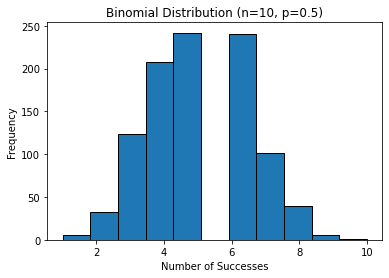

In [3]:
# 7. Simulate a dataset from a binomial distribution (n = 10, p = 0.5) using NumPy and plot the histogram.
import numpy as np
import matplotlib.pyplot as plt
# Simulate dataset
n = 10          # number of trials
p = 0.5         # probability of success
size = 1000     # number of samples
data = np.random.binomial(n, p, size)
# Plot histogram
plt.hist(data, bins=11, edgecolor='black')
plt.xlabel("Number of Successes")
plt.ylabel("Frequency")
plt.title("Binomial Distribution (n=10, p=0.5)")
plt.show()

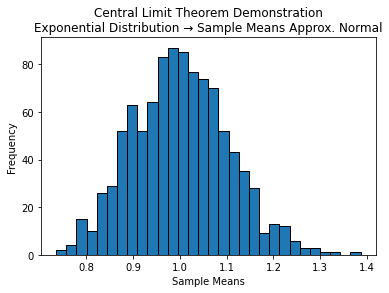

In [4]:
# 8. Generate multiple samples from a non-normal distribution and implement the Central Limit Theorem using Python.
import numpy as np
import matplotlib.pyplot as plt
num_samples = 1000      # number of repeated samples
sample_size = 100       # size of each sample
sample_means = []
for _ in range(num_samples):
    # Exponential distribution (non-normal)
    sample = np.random.exponential(scale=1.0, size=sample_size)
    sample_means.append(np.mean(sample))
plt.hist(sample_means, bins=30, edgecolor='black')
plt.xlabel("Sample Means")
plt.ylabel("Frequency")
plt.title("Central Limit Theorem Demonstration\nExponential Distribution → Sample Means Approx. Normal")
plt.show()

Sample Mean = 47.8136
95% Confidence Interval = (44.7664, 50.8609)


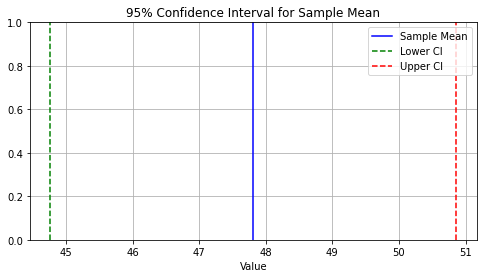

(47.813631615820604, 44.7664006732297, 50.86086255841151)

In [5]:
# 9. Write a Python function to calculate and visualize the confidence interval for a sample mean.
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
def plot_confidence_interval(data, confidence=0.95):
    # Convert to numpy array
    data = np.array(data)
    # Sample mean and standard error
    mean = np.mean(data)
    sem = stats.sem(data)
    # Confidence interval
    ci = stats.t.interval(confidence, df=len(data)-1, loc=mean, scale=sem)
    lower, upper = ci
    # Print Results
    print(f"Sample Mean = {mean:.4f}")
    print(f"{int(confidence*100)}% Confidence Interval = ({lower:.4f}, {upper:.4f})")
    # Plot
    plt.figure(figsize=(8, 4))
    plt.axvline(mean, color='blue', label='Sample Mean')
    plt.axvline(lower, color='green', linestyle='--', label='Lower CI')
    plt.axvline(upper, color='red', linestyle='--', label='Upper CI')
    plt.title(f"{int(confidence*100)}% Confidence Interval for Sample Mean")
    plt.xlabel("Value")
    plt.legend()
    plt.grid(True)
    plt.show()
    return mean, lower, upper
# Example Usage
np.random.seed(42)
sample_data = np.random.normal(loc=50, scale=10, size=40)
plot_confidence_interval(sample_data, confidence=0.95)

In [7]:
# 10. Perform a Chi-square goodness-of-fit test using Python to compare observed
# and expected distributions, and explain the outcome.
import numpy as np
from scipy.stats import chisquare
# Observed and expected frequencies
observed = np.array([30, 50, 20])
expected = np.array([33, 44, 23])
# Chi-square goodness-of-fit test
chi_stat, p_value = chisquare(f_obs=observed, f_exp=expected)
print("Chi-square Statistic =", chi_stat)
print("p-value =", p_value)
# Interpretation
alpha = 0.05
if p_value < alpha:
    print("\nResult: Reject the null hypothesis.")
    print("The observed distribution significantly differs from the expected distribution.")
else:
    print("\nResult: Fail to reject the null hypothesis.")
    print("There is no significant difference between observed and expected distribution.")
# Chi-square Statistic - Measures how far the observed values differ from expected values
# Probability of getting this level of difference if observed and expected are actually the same.
# If p-value < 0.05 → Significant difference
# If p-value ≥ 0.05 → No significant difference

Chi-square Statistic = 1.4822134387351777
p-value = 0.4765861763936037

Result: Fail to reject the null hypothesis.
There is no significant difference between observed and expected distribution.
